# 📘 ML System Optimization Assignment: Linear Regression with GPU

### Objective:
You are expected to design a parallel/distributed machine learning solution by integrating foundational optimization techniques and GPU-accelerated tools.

**Implemented Optimizers:**
- Batch Gradient Descent (BGD)
- Stochastic Gradient Descent (SGD)
- Gradient Descent with Momentum

**Tools:** CuPy, cuDF (GPU), scikit-learn (CPU)

**Dataset:** Boston Housing

---

## 🔹 Step 1: Data Preparation

We'll load the Boston Housing dataset, standardize it, and prepare it for GPU processing using CuPy and cuDF.

In [1]:
import cupy as cp
import cudf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split

# Load dataset from the original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

X_pd = pd.DataFrame(data)
y_pd = pd.Series(target)

# Standardize on CPU
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pd)
y = y_pd.values.reshape(-1, 1)

# Move to GPU
X_cp = cp.asarray(X_scaled)
y_cp = cp.asarray(y)

# Add bias term
X_cp = cp.hstack([cp.ones((X_cp.shape[0], 1)), X_cp])

# Train-test split
n_samples = X_cp.shape[0]
split = int(n_samples * 0.8)
X_train, X_test = X_cp[:split], X_cp[split:]
y_train, y_test = y_cp[:split], y_cp[split:]

# Use CPU-side standardized data
X_train_cpu, X_test_cpu, y_train_cpu, y_test_cpu = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

sgd_cpu = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01, penalty=None)
start = time.time()
sgd_cpu.fit(X_train_cpu, y_train_cpu.ravel())
end = time.time()

y_pred_cpu = sgd_cpu.predict(X_test_cpu)
mse_cpu = mean_squared_error(y_test_cpu, y_pred_cpu)

print(f"Final MSE (SGDRegressor CPU): {mse_cpu:.4f}")
print(f"Training Time (CPU): {end - start:.4f} sec")

Final MSE (SGDRegressor CPU): 28.1116
Training Time (CPU): 0.0019 sec


## 🔹 Step 2: Batch Gradient Descent (BGD)

We now implement BGD using CuPy. We'll track the loss per epoch and plot the convergence curve.

Final MSE (BGD): 23.8422
Training Time (BGD): 2.6259 sec


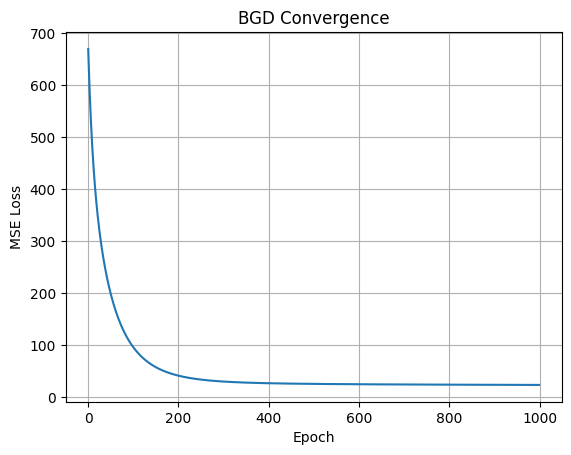

In [3]:

epochs = 1000
lr = 0.01
loss_bgd = []
w_bgd = cp.zeros((X_train.shape[1], 1))

start = time.time()
for epoch in range(epochs):
    pred = X_train @ w_bgd
    error = pred - y_train
    grad = X_train.T @ error / X_train.shape[0]
    w_bgd -= lr * grad
    loss = cp.mean((error) ** 2)
    loss_bgd.append(cp.asnumpy(loss))
end = time.time()

print(f"Final MSE (BGD): {loss_bgd[-1]:.4f}")
print(f"Training Time (BGD): {end - start:.4f} sec")

plt.plot(loss_bgd)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("BGD Convergence")
plt.grid(True)
plt.show()


## 🔹 Step 3: Stochastic Gradient Descent (SGD)

Now we'll implement SGD using CuPy. Unlike BGD, weights are updated for each sample. We'll track the loss and visualize convergence.

Final MSE (SGD): 23.2240
Training Time (SGD): 2.9431 sec


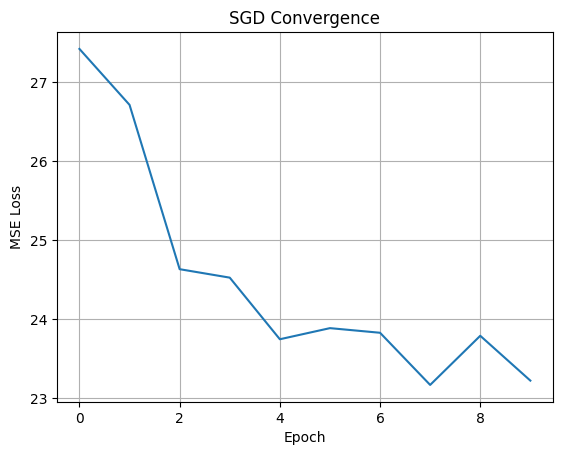

In [4]:

epochs = 10  # Fewer epochs since each sample updates weights
lr = 0.01
loss_sgd = []
w_sgd = cp.zeros((X_train.shape[1], 1))

start = time.time()
for epoch in range(epochs):
    perm = cp.random.permutation(X_train.shape[0])
    for i in perm:
        xi = X_train[i].reshape(1, -1)
        yi = y_train[i].reshape(1, 1)
        pred = xi @ w_sgd
        error = pred - yi
        grad = xi.T @ error
        w_sgd -= lr * grad
    # Calculate MSE after full epoch
    epoch_pred = X_train @ w_sgd
    epoch_error = epoch_pred - y_train
    loss = cp.mean(epoch_error ** 2)
    loss_sgd.append(cp.asnumpy(loss))
end = time.time()

print(f"Final MSE (SGD): {loss_sgd[-1]:.4f}")
print(f"Training Time (SGD): {end - start:.4f} sec")

plt.plot(loss_sgd)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SGD Convergence")
plt.grid(True)
plt.show()


## 🔹 Step 4: Gradient Descent with Momentum

We now implement Gradient Descent with Momentum. This adds a velocity term to the gradient update to help accelerate convergence.

Final MSE (Momentum): 22.7784
Training Time (Momentum): 0.8205 sec


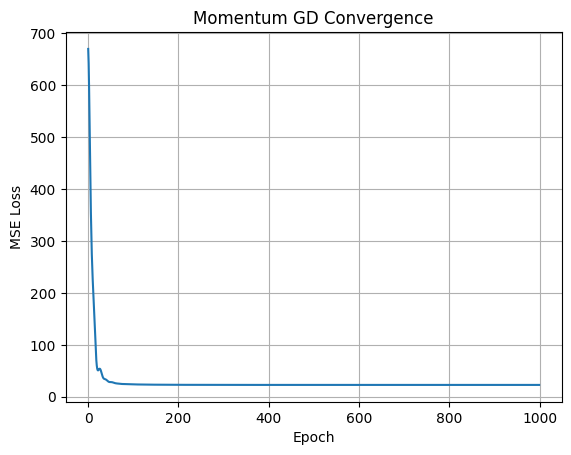

In [5]:

epochs = 1000
lr = 0.01
momentum = 0.9
loss_mom = []
w_mom = cp.zeros((X_train.shape[1], 1))
velocity = cp.zeros_like(w_mom)

start = time.time()
for epoch in range(epochs):
    pred = X_train @ w_mom
    error = pred - y_train
    grad = X_train.T @ error / X_train.shape[0]
    velocity = momentum * velocity + lr * grad
    w_mom -= velocity
    loss = cp.mean(error ** 2)
    loss_mom.append(cp.asnumpy(loss))
end = time.time()

print(f"Final MSE (Momentum): {loss_mom[-1]:.4f}")
print(f"Training Time (Momentum): {end - start:.4f} sec")

plt.plot(loss_mom)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Momentum GD Convergence")
plt.grid(True)
plt.show()


In [2]:
import psutil, os
process = psutil.Process(os.getpid())
print(f"CPU memory used: {process.memory_info().rss / (1024 ** 2):.2f} MB")

CPU memory used: 610.47 MB
